# Segundo momento evaluativo

Realiza los ejercicios únicamente utilizando los temas desarrollados en clase y tareas.

### 1.- Atenúa el ruido en la imagen ruido.jpg tal cual se ve en el ejemplo:

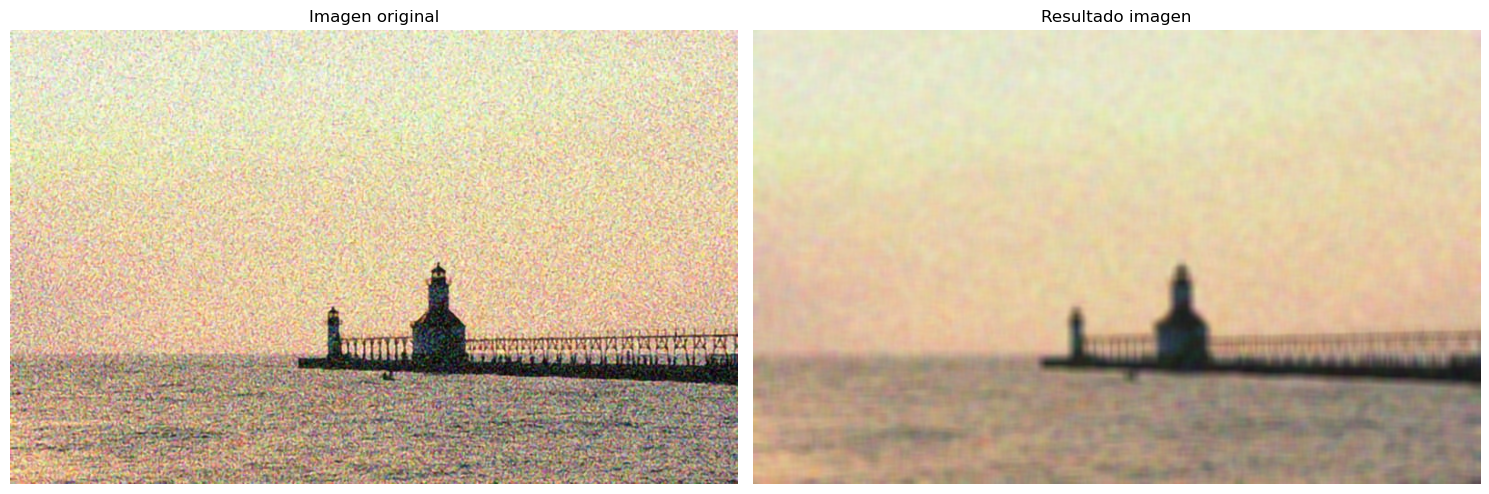

In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def convolucion_media_horizontal(imagen, tamanioKernel):
  kernel = np.ones((1, tamanioKernel), np.float32) / tamanioKernel
  img_final = cv2.filter2D(imagen, -1, kernel)
  return img_final

def convolucion_media_vertical(imagen, tamanioKernel):
  kernel = np.ones((tamanioKernel, 1), np.float32) / tamanioKernel
  img_final = cv2.filter2D(imagen, -1, kernel)
  return img_final

img = cv2.imread('./images/ruido.jpg')

resultado = convolucion_media_horizontal(img, 11)
resultado = convolucion_media_vertical(resultado, 11)

plt.figure(figsize=(15, 7))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Imagen original')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(resultado, cv2.COLOR_BGR2RGB))
plt.title('Resultado imagen')
plt.axis('off')

plt.tight_layout()
plt.show()

### 2.- Usando la imagen “rosa.png” obtenga el siguiente resultado:

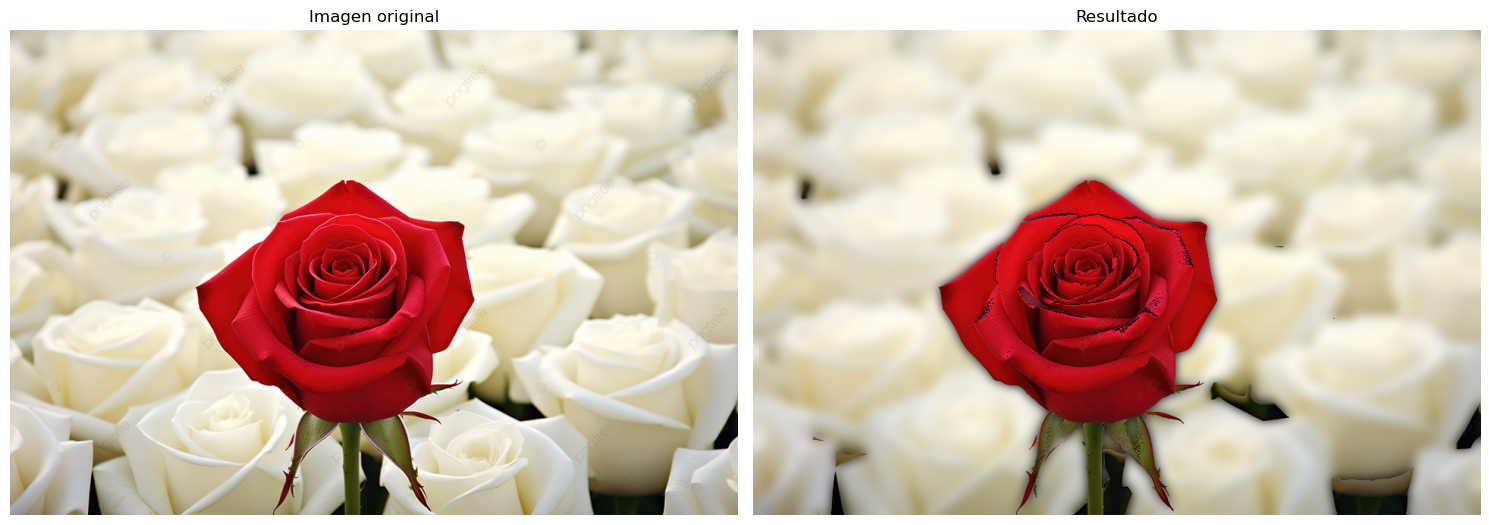

In [30]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def aplicarDesenfoque(img, umbral=127):
  img_gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
  _, img_bin = cv2.threshold(img_gris, umbral, 255, cv2.THRESH_BINARY)
  mascara = np.zeros_like(img)
  mascara[:, :, 0] = img_bin
  mascara[:, :, 1] = img_bin
  mascara[:, :, 2] = img_bin
  img_mascara = cv2.bitwise_and(img, mascara)
  desenfoque = cv2.GaussianBlur(img_mascara, (45, 45), 0)

  img1 = img.copy()
  # img1[mascara != 0] = desenfoque[mascara != 0]
  for i in range(img1.shape[0]):
    for j in range(img1.shape[1]):
      if mascara[i, j, 0] != 0:
        img1[i, j] = desenfoque[i, j]
      else:
        img1[i, j] = img[i, j]
  return img1

img = cv2.imread('./images/rosa.png')
resultado = aplicarDesenfoque(img, 100)

plt.figure(figsize=(15, 7))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Imagen original')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(resultado, cv2.COLOR_BGR2RGB), cmap='gray')
plt.title('Resultado')
plt.axis('off')

plt.tight_layout()
plt.show()

### 3.- Usando la imagen “Elementos jpg” obtenga el siguiente resultado.

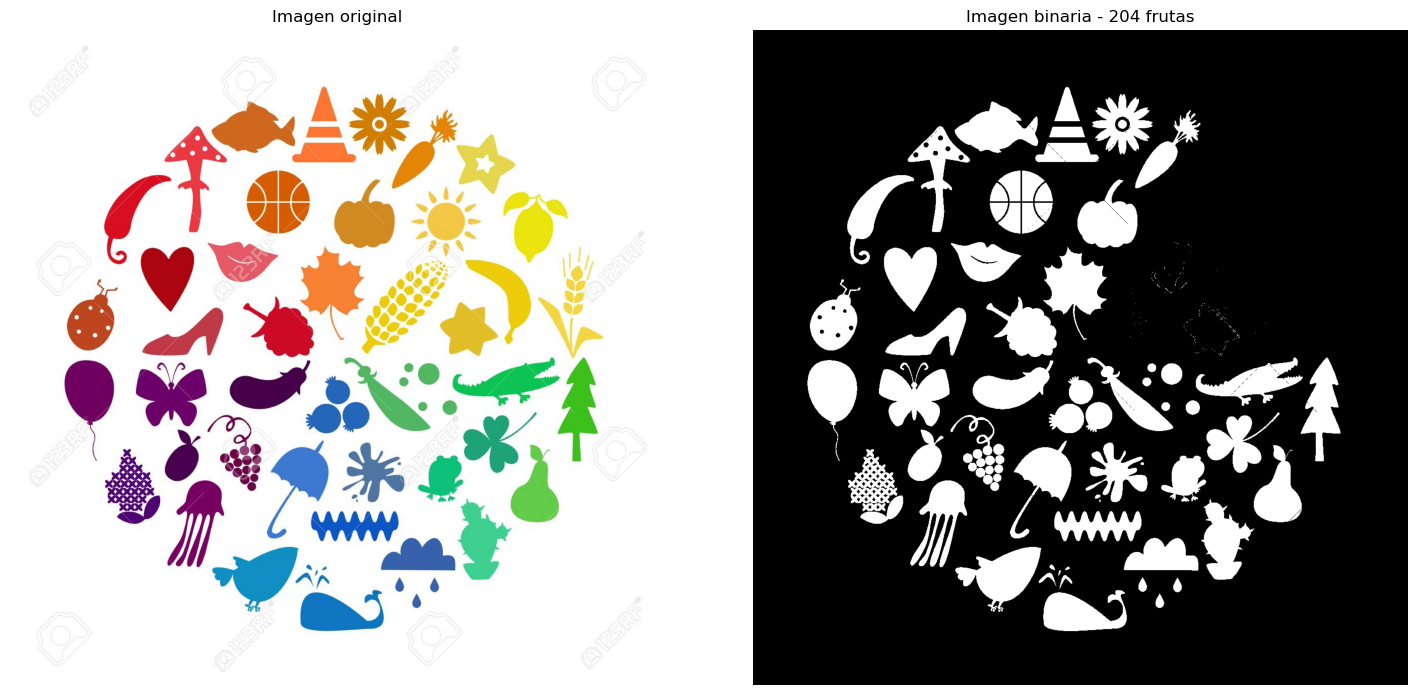

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def conteo(img):
  img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
  _, img_bin = cv2.threshold(img_gray, 178, 255, cv2.THRESH_BINARY_INV)
  borde, _ = cv2.findContours(img_bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
  conteo = len(borde)
  return conteo, img_bin

img = cv2.imread('./images/elementos.jpg')
conteo, img_bin = conteo(img)

plt.figure(figsize=(15, 7))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Imagen original')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_bin, cmap='gray')
plt.title(f'Imagen binaria - {conteo} frutas')
plt.axis('off')

plt.tight_layout()
plt.show()

### 4.- Usando la imagen Cristo obtiene el siguiente resultado (utiliza máscaras de convolución)

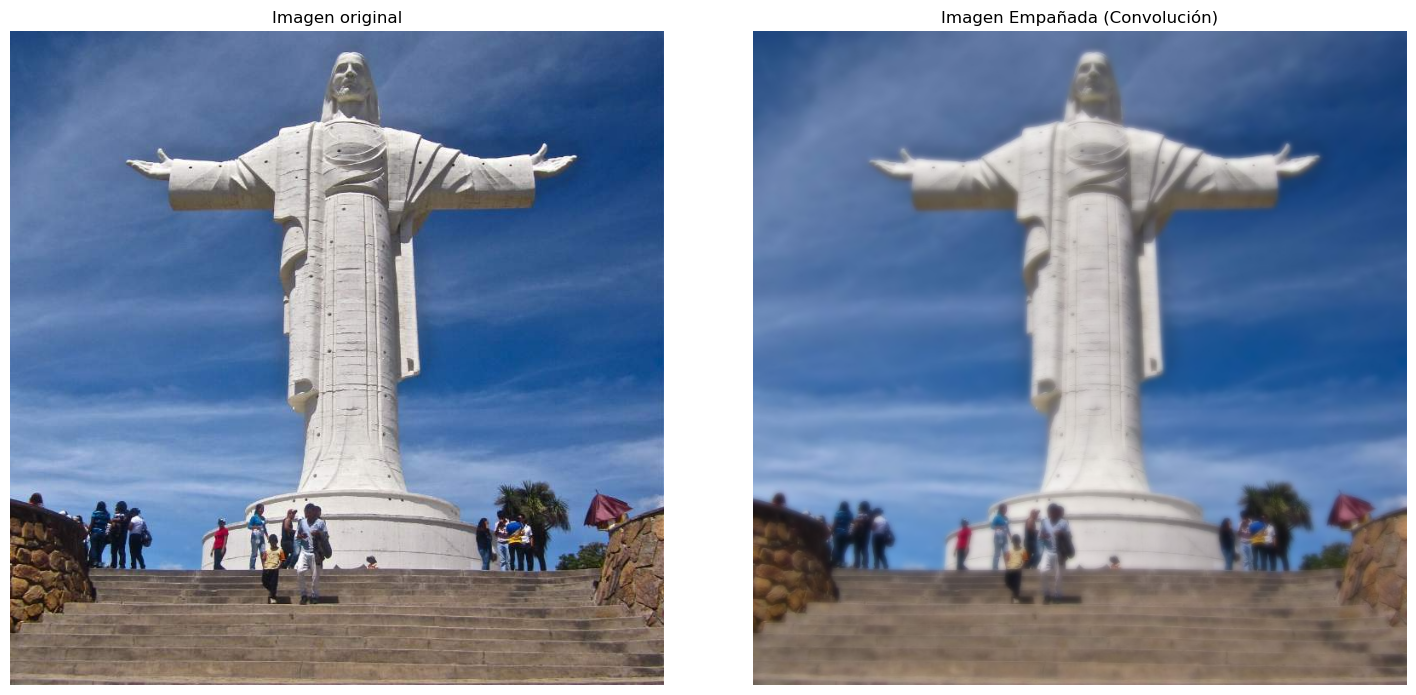

In [97]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def aplicar_filtro(img):
  img1 = img.copy()
  img1 = cv2.GaussianBlur(img1, (19, 19), 0)
  result = cv2.addWeighted(img, 0.2, img1, 0.80, 0)
  return result

img = cv2.imread('./images/cristo.jpg')
resultado = aplicar_filtro(img)

plt.figure(figsize=(15, 7))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Imagen original')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(resultado, cv2.COLOR_BGR2RGB))
plt.title('Imagen Empañada (Convolución)')
plt.axis('off')

plt.tight_layout()
plt.show()

### 5.- Realiza una combinación de técnicas con una fotografía tuya (utiliza las técnicas de bordes) explica las diferencias

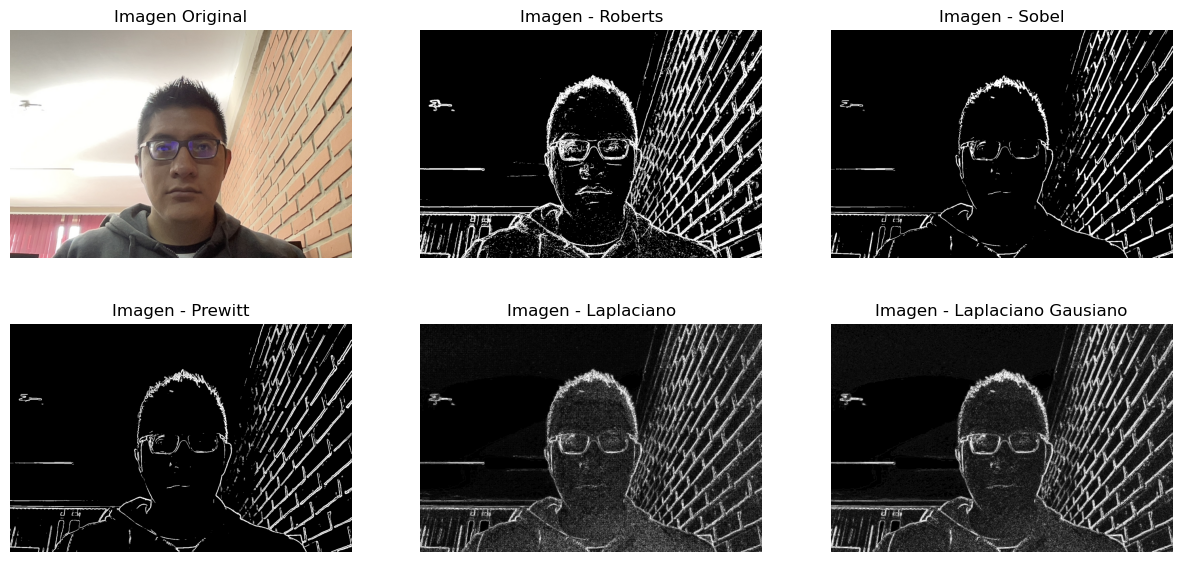

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

kernel_roberts_x = np.array([[-1, 0],
                             [0, 1]])
kernel_roberts_y = np.array([[0, -1],
                             [1, 0]])

def roberts(img):
  img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
  suavizado = cv2.GaussianBlur(img_gray, (3, 3), 0)

  kernel_x = 5 * kernel_roberts_x
  kernel_y = 5 * kernel_roberts_y

  img_bordes_roberts_x = cv2.filter2D(suavizado, cv2.CV_16S, kernel_x)
  img_bordes_roberts_y = cv2.filter2D(suavizado, cv2.CV_16S, kernel_y)

  roberts = cv2.addWeighted(np.abs(img_bordes_roberts_x), 0.7, np.abs(img_bordes_roberts_y), 0.7, 0)
  _, bordes = cv2.threshold(roberts, 30, 255, cv2.THRESH_BINARY)
  return bordes

def sobel(img, tam_kernel=3, umbral=30):
  img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
  suavizado = cv2.GaussianBlur(img_gray, (3, 3), 0)
  
  sobel_x = cv2.Sobel(suavizado, cv2.CV_64F, 1, 0, ksize=tam_kernel, scale=5)
  sobel_y = cv2.Sobel(suavizado, cv2.CV_64F, 0, 1, ksize=tam_kernel, scale=5)
  
  magnitud = np.sqrt(sobel_x**2 + sobel_y**2)
  magnitud = cv2.normalize(magnitud, None, 0, 255, cv2.NORM_MINMAX, cv2.CV_8U)

  _, bordes = cv2.threshold(magnitud, umbral, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

  # Unir bordes rotos
  kernel_morf = np.ones((2, 2), np.uint8)
  bordes = cv2.morphologyEx(bordes, cv2.MORPH_CLOSE, kernel_morf)
  
  return bordes

def prewitt(img):
  img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
  suavizado = cv2.GaussianBlur(img_gray, (3, 3), 0)
  
  kernel_prewitt_x = 5 * np.array([[1, 0, -1],
                                  [1, 0, -1],
                                  [1, 0, -1]], dtype=np.float32)
  kernel_prewitt_y = 5 * np.array([[1, 1, 1],
                                  [0, 0, 0],
                                  [-1, -1, -1]], dtype=np.float32)
  
  prewitt_x = cv2.filter2D(suavizado, cv2.CV_64F, kernel_prewitt_x)
  prewitt_y = cv2.filter2D(suavizado, cv2.CV_64F, kernel_prewitt_y)
  
  magnitud = np.sqrt(prewitt_x**2 + prewitt_y**2)
  magnitud = cv2.normalize(magnitud, None, 0, 255, cv2.NORM_MINMAX, cv2.CV_8U)

  # _, bordes = cv2.threshold(magnitud, 30, 255, cv2.THRESH_BINARY)
  _, bordes = cv2.threshold(magnitud, 30, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
  return bordes

def laplaciano(img, tamanio_kernel=3):
  img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
  laplaciano = cv2.Laplacian(img_gray, cv2.CV_16S, ksize=tamanio_kernel, scale=3)
  laplaciano = cv2.convertScaleAbs(laplaciano)
  return laplaciano

def laplacianoGaussiano(img, tamanio_kernel=3):
  gaussiano = cv2.GaussianBlur(img, (tamanio_kernel, tamanio_kernel), 0)
  img_gray = cv2.cvtColor(gaussiano, cv2.COLOR_BGR2GRAY)
  resultado = cv2.Laplacian(img_gray, cv2.CV_16S, ksize=tamanio_kernel, scale=5)
  resultado = cv2.convertScaleAbs(resultado)
  return resultado

img = cv2.imread('./images/gonzalo.jpg')
img_roberts = roberts(img)
img_sobel = sobel(img)
img_prewitt = prewitt(img)
img_laplaciano = laplaciano(img)
img_laplaciano_gaussiano = laplacianoGaussiano(img)

plt.figure(figsize=(15, 7))

plt.subplot(2, 3, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Imagen Original')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(img_roberts, cmap='gray')
plt.title('Imagen - Roberts')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.imshow(img_sobel, cmap='gray')
plt.title('Imagen - Sobel')
plt.axis('off')

plt.subplot(2, 3, 4)
plt.imshow(img_prewitt, cmap='gray')
plt.title('Imagen - Prewitt')
plt.axis('off')

plt.subplot(2, 3, 5)
plt.imshow(img_laplaciano, cmap='gray')
plt.title('Imagen - Laplaciano')
plt.axis('off')

plt.subplot(2, 3, 6)
plt.imshow(img_laplaciano_gaussiano, cmap='gray')
plt.title('Imagen - Laplaciano Gausiano')
plt.axis('off')

plt.show()

1. Roberts: Se utiliza en lugares donde queremos mucha precision ya que trabaja con un tamaño de kernel pequeño, trabaja en dos direcciones y se tiene que combinar para tener el resultado final.
2. Sobel: Trabaja con un tamaño de kernel variable y se puede ajustar la precisión de los bordes, trabaja con dos direcciones y se tiene que combinar para tener el resultado final.
3. Prewitt: Trabaja con un kernel de 3x3, se aplica en dos direcciones que se combinan para un resultado final.
4. Laplaciano: Aplica el gradiente laplaciano que se basa en encontrar la doble deribada de la intensidad y obtener los lugares en donde su valor es cero (bordes).
5. Laplaciano Gausiano: Suaviza primero la imagen y luego aplica el gradiente laplaciano, se utiliza cuando tenemos imagenes con ruido, ya que este es el que mejor resultados nos da.


### 6.- Realiza el código del lapaciano y lapaciano del gausiano mejorando los bordes (deben verse más nítidos los bordes encontrados)

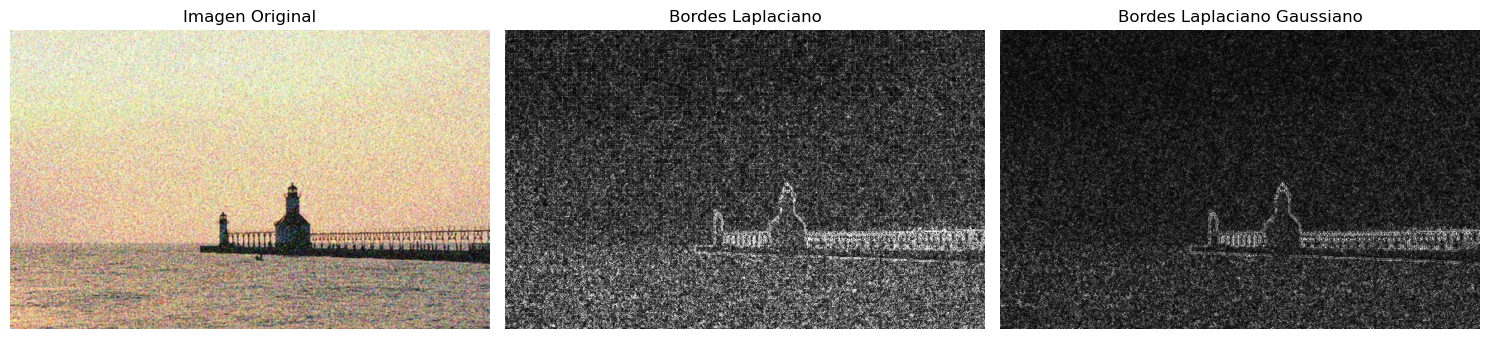

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def laplaciano(img, tamanio_kernel=3):
  img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
  laplaciano = cv2.Laplacian(img_gray, cv2.CV_16S, ksize=tamanio_kernel)
  laplaciano = cv2.convertScaleAbs(laplaciano)
  return laplaciano

def laplacianoGaussiano(img, tamanio_kernel=3):
  gaussiano = cv2.GaussianBlur(img, (tamanio_kernel, tamanio_kernel), 0)
  img_gray = cv2.cvtColor(gaussiano, cv2.COLOR_BGR2GRAY)
  resultado = cv2.Laplacian(img_gray, cv2.CV_16S, ksize=tamanio_kernel)
  resultado = cv2.convertScaleAbs(resultado)
  return resultado

img = cv2.imread('./images/ruido.jpg')

img_laplaciano = laplaciano(img)
img_laplaciano_gaussiano = laplacianoGaussiano(img)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Imagen Original')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(img_laplaciano, cmap='gray')
plt.title('Bordes Laplaciano')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(img_laplaciano_gaussiano, cmap='gray')
plt.title('Bordes Laplaciano Gaussiano')
plt.axis('off')

plt.tight_layout()
plt.show()